In [69]:
import matplotlib.pylab as plt
import numpy as np
import tidy3d as td
import tidy3d.web as web

## Initial Design in 2D

We start with the 2D design and aim to optimize its coupling efficiency as much as possible. This way, the design process is faster and costs fewer FlexCredits.

First define the wavelength range of interest.

In [70]:
lda0 = 1.31  # central wavelength
freq0 = td.C_0 / lda0  # central frequency
npts = 101  # number of points in the wavelength range
ldas = np.linspace(1.2, 1.4, npts)  # wavelength range
freqs = td.C_0 / ldas  # frequency range
fwidth = 0.5 * (np.max(freqs) - np.min(freqs))  # width of the source frequency range

Grating couplers are relatively narrow band device. Within the working bandwidth, the refractive indices of silicon and oxide don't change noticeably. Therefore, for simplicity we will just model them as nondispersive mediums. 

In [113]:
si_toc = 1.8e-4 # Thermo-optic coefficient of silicon (K^-1)
si3n4_toc = 2.5e-5 # Thermo-optic coefficient of silicon nitride (K^-1)
sio2_toc = 8.4E-6 # Thermo-optic coeffici   ent of silicon dioxide (K^-1)
tio2_toc = -2e-4 # Thermo-optic coefficient of titanium dioxide (K^-1)

n_si = 3.48
si = td.Medium(permittivity=n_si**2)
n_si3n4 = 1.96274
si3n4 = td.Medium(permittivity=n_si3n4**2)
n_sio2 = 1.44384
sio2 = td.Medium(permittivity=n_sio2**2)
n_tio2 = 2.4
tio2 = td.Medium(permittivity=n_tio2**2)

def create_mats(temp=25):
    if temp > 25:
        n_si = 3.48 + si_toc * (temp - 25)
        si = td.Medium(permittivity=n_si**2)
    else:
        n_si = 3.48
        si = td.Medium(permittivity=n_si**2)

    if temp > 25:
        n_si3n4 = 1.96274 + si3n4_toc * (temp - 25)
        si3n4 = td.Medium(permittivity=n_si3n4**2)
    else:
        n_si3n4 = 1.96274
        si3n4 = td.Medium(permittivity=n_si3n4**2)

    if temp > 25:
        n_sio2 = 1.44384 + sio2_toc * (temp - 25)
        sio2 = td.Medium(permittivity=n_sio2**2)
    else:
        n_sio2 = 1.44384
        sio2 = td.Medium(permittivity=n_sio2**2)

    if temp > 25:
        n_tio2 = 2.4 + tio2_toc * (temp - 25)
        tio2 = td.Medium(permittivity=n_tio2**2)
    else:
        n_tio2 = 2.4
        tio2 = td.Medium(permittivity=n_tio2**2)
    return si, si3n4, sio2, tio2

Define geometry parameters. In this case, we have a silicon layer of 260 nm thickness. The grating will be partially etched with an etching depth of 160 nm. The filling fraction is set to be 80% in this case. A higher filling fraction will lead to a smaller gap size so this needs to be chosen according to the fabrication. The BOX layer has a thickness of 2 μm and the top oxide cladding has a thickness of 680 nm. 

In [72]:
t_si3n4 = 0.4  # thickness of the silicon nitride layer
t_tox = 0.08  # top oxide layer thickness
t_box = 5.0  # bottom oxide layer thickness

The goal is to couple between a single-mode waveguide and a single-mode fiber with a mode field diameter of 10.8 μm at an angle of 14.5 degrees.

In [73]:
theta = np.deg2rad(0)  # fiber tilt angle
mfd = 9.0  # mode field diameter

inf_eff = 1.0e3  # effective infinity
buffer = 0.6 * lda0  # buffer spacing to pad the simulation domain

Next we define some [Structures](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Structure.html) that are not changing in the design. This includes the top oxide layer, BOX layer, slab waveguide layer, etc. 

In [ ]:
# create the top oxide layer
tox = td.Structure(
    geometry=td.Box.from_bounds(rmin=(-inf_eff, -inf_eff, 0), rmax=(inf_eff, inf_eff, t_tox)),
    medium=sio2,
)

# create the slab waveguide
slab_waveguide = td.Structure(
    geometry=td.Box.from_bounds(rmin=(-inf_eff, -inf_eff, 0), rmax=(0, inf_eff, t_si3n4)),
    medium=si3n4,
)

# create the bottom oxide layer
box = td.Structure(
    geometry=td.Box.from_bounds(rmin=(-inf_eff, -inf_eff, -t_box), rmax=(inf_eff, inf_eff, 0)),
    medium=sio2,
)

# create the silicon substrate layer
substrate = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-inf_eff, -inf_eff, -inf_eff), rmax=(inf_eff, inf_eff, -t_box)
    ),
    medium=si,
)

In [133]:
w_wg = 0.8  # waveguide width
l_taper = 4.0  # length of the linear taper

def make_3d_sim(t_tox,
                temp=25) -> td.Simulation:
    """Create a 3D simulation with the given parameters.
    Args:
        t_tox (float): Thickness of the top oxide layer.
        temp (float): Temperature in degrees Celsius.
    Returns:
        td.Simulation: The simulation object.
    """
    si, si3n4, sio2, tio2 = create_mats(temp)

    # create the top oxide layer
    tox = td.Structure(
        geometry=td.Box.from_bounds(rmin=(-inf_eff, -inf_eff, 0), rmax=(inf_eff, inf_eff, t_tox)),
        medium=sio2,
    )

    # create the slab waveguide
    slab_waveguide = td.Structure(
        geometry=td.Box.from_bounds(rmin=(-inf_eff, -inf_eff, 0), rmax=(0, inf_eff, t_si3n4)),
        medium=si3n4,
    )

    # create the bottom oxide layer
    box = td.Structure(
        geometry=td.Box.from_bounds(rmin=(-inf_eff, -inf_eff, -t_box), rmax=(inf_eff, inf_eff, 0)),
        medium=sio2,
    )

    # create the silicon substrate layer
    substrate = td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-inf_eff, -inf_eff, -inf_eff), rmax=(inf_eff, inf_eff, -t_box)
        ),
        medium=si,
    )

    source_gap = 0.5

    # define a gaussian beam source
    source = td.GaussianBeam(
        size=(2 * mfd, 2 * mfd, 0),
        center=[l_taper/2, 0, t_tox + source_gap],
        source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth),
        angle_theta=theta,
        direction="-",
        waist_radius=mfd / 2,
        pol_angle=np.pi / 2,  # 90 degree polarization angle for TE polarization
    )

    # define a mode monitor
    mode_monitor = td.ModeSolverMonitor(
        center=(-
                 -buffer - l_taper/2 + 0.5, 0, t_si3n4 / 2),
        size=(0, 6 * w_wg, 6 * t_si3n4),
        freqs=freqs,
        mode_spec=td.ModeSpec(num_modes=1, 
                              group_index_step=True,
                              precision='double',
                              target_neff=n_si3n4),
        name="mode",
    )

    # create the slab waveguide
    wg = td.Structure(
        geometry=td.Box.from_bounds(rmin=(-l_taper/2, -w_wg/2, 0), 
                                    rmax=(l_taper/2, w_wg/2, t_si3n4)),
        medium=si3n4,
    )

    # create a box to represent the simulation domain box
    sim_box = td.Box.from_bounds(
        rmin=(-buffer - l_taper/2, 
              -4*w_wg - buffer, 
              -t_box - buffer),
        rmax=(l_taper/2 + buffer, 
              4*w_wg + buffer, 
              t_si3n4 + t_tox + buffer),
    )

    run_time = 1e-12  # simulation run time
    # Refine the grid over the GC region.
    refine_box = td.MeshOverrideStructure(
        geometry=td.Box(center=(buffer + l_taper / 2, 0, 0), 
                        size=(td.inf, td.inf, 2 * t_si3n4)),
        dl=[0.02, 0.02, 0.02],
    )
    # construct simulation
    sim = td.Simulation(
        center=sim_box.center,
        size=sim_box.size,
        grid_spec = td.GridSpec(grid_x = td.AutoGrid(min_steps_per_wvl = 20, ),
                                grid_y = td.AutoGrid(min_steps_per_wvl = 20, ), 
                                grid_z = td.AutoGrid(min_steps_per_wvl = 20, ), 
                                wavelength = lda0,
                                override_structures=[refine_box],
                                ), 
        subpixel = td.SubpixelSpec(dielectric = td.PolarizedAveraging(), 
                                metal = td.Staircasing(), 
                                pec = td.PECConformal(timestep_reduction = 0.3), ),         
        structures=[
            tox,
            # etched_waveguide,
            wg,
            box,
            substrate,
        ],
        sources=[source],
        monitors=[mode_monitor],
        run_time=run_time,
        symmetry=(0, -1, 0),
    )
    return sim

Generate the simulation using the optimal parameters from the 2D design. 

In [134]:
t_toxs = [5] #np.linspace(0.05, 0.15, 5)  # top oxide layer thicknesses
dwls = []  # list to store the wavelength shifts
for t_tox in t_toxs:
    print(f"t_tox: {t_tox:.2f} um")
    n_effs = []
    for temp in [25, 26]:
        sim_3d = make_3d_sim(t_tox=t_tox, 
                             temp=temp)
        sim_data = web.run(simulation=sim_3d, task_name="3D_GC")
        neffs = (sim_data["mode"].n_eff)
        neff = neffs[np.ceil(npts/2).astype(int)]
        ng = sim_data["mode"].n_group[0]
        n_effs.append(neff)
    dwl = 1e6*lda0*(neffs[1]-neffs[0])/(ng)
    dwls.append(dwl)  # store the wavelength shift in the list

t_tox: 5.00 um


11:45:44 PM Eastern Daylight Time Created task '3D_GC' with task_id             
                                  'fdve-7d804d26-8708-46fe-987a-a016e770f0cf'   
                                  and task_type 'FDTD'.

                                  View task using web UI at                     
                                  ]8;id=205865;https://tidy3d.simulation.cloud/workbench?taskId=fdve-7d804d26-8708-46fe-987a-a016e770f0cf\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=638967;https://tidy3d.simulation.cloud/workbench?taskId=fdve-7d804d26-8708-46fe-987a-a016e770f0cf\tas]8;;\
                                  ]8;id=638967;https://tidy3d.simulation.cloud/workbench?taskId=fdve-7d804d26-8708-46fe-987a-a016e770f0cf\kId]8;;\]8;id=205865;https://tidy3d.simulation.cloud/workbench?taskId=fdve-7d804d26-8708-46fe-987a-a016e770f0cf\=]8;;\]8;id=847551;https://tidy3d.simulation.cloud/workbench?taskId=fdve-7d804d26-8708-46fe-987a-a016e770f0cf\fdve]8;;\]8;id=205865;https://tidy3d.simulation.cloud/workbench?taskId=fdve-7d804d26-8708-46fe-987a-a016e770f0cf\-7d804d26-8708-46fe-987a-a016e770f0cf']8;;\
                                  .

Output()

11:45:48 PM Eastern Daylight Time status = queued

...

Output()

11:52:40 PM Eastern Daylight Time status = success

                                  View simulation result at                     
                                  ]8;id=818047;https://tidy3d.simulation.cloud/workbench?taskId=fdve-b2be64ba-ee8c-4879-88fa-5748c27d312a\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=942118;https://tidy3d.simulation.cloud/workbench?taskId=fdve-b2be64ba-ee8c-4879-88fa-5748c27d312a\tas]8;;\
                                  ]8;id=942118;https://tidy3d.simulation.cloud/workbench?taskId=fdve-b2be64ba-ee8c-4879-88fa-5748c27d312a\kId]8;;\]8;id=818047;https://tidy3d.simulation.cloud/workbench?taskId=fdve-b2be64ba-ee8c-4879-88fa-5748c27d312a\=]8;;\]8;id=559453;https://tidy3d.simulation.cloud/workbench?taskId=fdve-b2be64ba-ee8c-4879-88fa-5748c27d312a\fdve]8;;\]8;id=818047;https://tidy3d.simulation.cloud/workbench?taskId=fdve-b2be64ba-ee8c-4879-88fa-5748c27d312a\-b2be64ba-ee8c-4879-88fa-5748c27d312a']8;;\
                                  .

Output()

11:53:38 PM Eastern Daylight Time loading simulation from simulation_data.hdf5

In [135]:
dwls

[<xarray.ModeIndexDataArray (mode_index: 1)> Size: 8B
 array([-382.52723202])
 Coordinates:
   * mode_index  (mode_index) int64 8B 0
     f           float64 8B 2.498e+14]

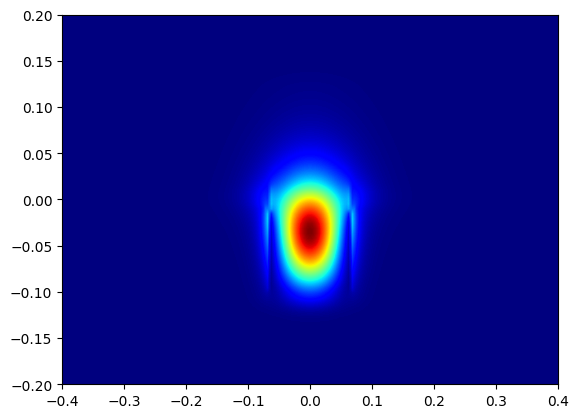

In [104]:
eys1 = (np.abs(sim_data["mode"].Ey)**2)[0,:, :, 0]
np.shape(eys1[:,:,0].T)
plt.imshow(eys1[:,:,0].T, 
           extent=(-w_wg/2, w_wg/2, 
                   -t_si3n4/2, t_si3n4/2), 
           aspect='auto',
           cmap='jet',
           interpolation='bilinear')
